In [18]:
#Import modules
import sys
sys.path.append('../')
sys.path.append('../modules')
from Class_sem2dpack import *
from Stage_module import *
from houches_fb import *
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as anim

#Load data
direct1 = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Prenolin_Multicouche"
is_overburden = False
fmin, fmax = 0.01, 50.0
SEM = sem2dpack(direct1)


Reading grid information...
Reading header file...
0.00019999999 50001 130
--- No extra station ---
*


c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:330: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  line = pd.read_csv(fname, delim_whitespace=True, header=None, nrows=1, dtype=int)
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:331: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, names=('x','z'), delim_whitespace=True, header=0, nrows=line.values[0][0])
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:365: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, header=0, n

Filtering seissmograms ...
Filtering seissmograms ...


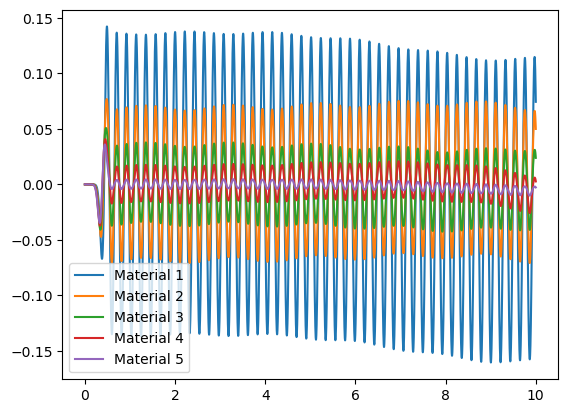

In [19]:
SEM.read_seismo('x')
SEM.filter_seismo(fmax=fmax, ftype='lowpass')
SEM.filter_seismo(fmin=fmin, ftype='highpass')
Time_stations = SEM.time
Vx = SEM.velocity[:,:]
XSTA, ZSTA = SEM.rcoord[:,0], SEM.rcoord[:,1]


s1 = get_nearest_station(2.5,-5,XSTA,ZSTA)
Vs1 = 300
s2 = get_nearest_station(2.5,-15,XSTA,ZSTA)
Vs2 = 2*300
s3 = get_nearest_station(2.5,-25,XSTA,ZSTA)
Vs3 = 3*300
s4 = get_nearest_station(2.5,-35,XSTA,ZSTA)
Vs4 = 4*300
s5 = get_nearest_station(2.5,-45,XSTA,ZSTA)
Vs5 = 5*300


plt.plot(Time_stations,Vx[:,s1],label="Material 1")
plt.plot(Time_stations,Vx[:,s2],label="Material 2")
plt.plot(Time_stations,Vx[:,s3],label="Material 3")
plt.plot(Time_stations,Vx[:,s4],label="Material 4")
plt.plot(Time_stations,Vx[:,s5],label="Material 5")
plt.legend()
plt.show()

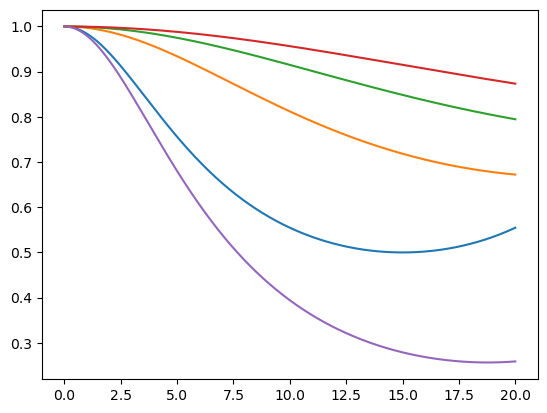

In [20]:
def Haskell_Thomson(f, Vs_plus, Vs_moins):
    Ks = 2*np.pi*f/Vs_moins
    alpha = Vs_moins/Vs_plus
    H=10
    coeff = np.sqrt(np.cos(Ks*H)**2 + (alpha*np.sin(Ks*H))**2)
    return 1/coeff

F = np.linspace(1e-3,20,1000)
product = Haskell_Thomson(F,Vs1,Vs2)*Haskell_Thomson(F,Vs2,Vs3)*Haskell_Thomson(F,Vs3,Vs4)*Haskell_Thomson(F,Vs4,Vs5)
plt.plot(F, Haskell_Thomson(F,Vs1,Vs2))
plt.plot(F, Haskell_Thomson(F,Vs2,Vs3))
plt.plot(F, Haskell_Thomson(F,Vs3,Vs4))
plt.plot(F, Haskell_Thomson(F,Vs4,Vs5))
plt.plot(F,product)

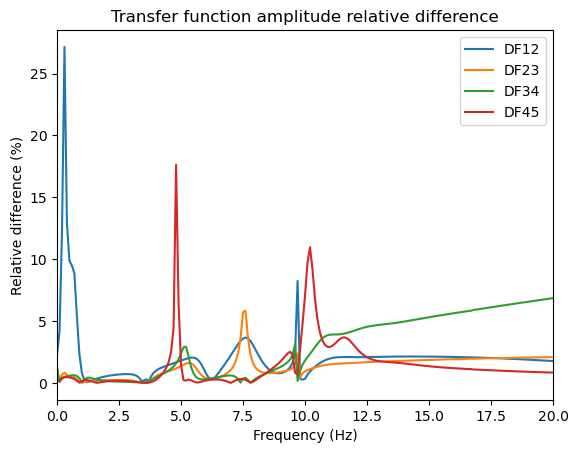

In [21]:
dt = Time_stations[1]-Time_stations[0]
FFT1, freq = fourier(Vx[:,s1],dt)
FFT2, freq = fourier(Vx[:,s2],dt)
FFT3, freq = fourier(Vx[:,s3],dt)
FFT4, freq = fourier(Vx[:,s4],dt)
FFT5, freq = fourier(Vx[:,s5],dt)
#plt.plot(freq,FFT1/FFT2)
plt.xlim([0,20])

product = Haskell_Thomson(freq,Vs1,Vs2)*Haskell_Thomson(freq,Vs2,Vs3)*Haskell_Thomson(freq,Vs3,Vs4)*Haskell_Thomson(freq,Vs4,Vs5)

DF12 = abs(FFT1/FFT2-Haskell_Thomson(freq,Vs1,Vs2))/Haskell_Thomson(freq,Vs1,Vs2)
DF23 = abs(FFT2/FFT3-Haskell_Thomson(freq,Vs2,Vs3))/Haskell_Thomson(freq,Vs2,Vs3)
DF34 = abs(FFT3/FFT4-Haskell_Thomson(freq,Vs3,Vs4))/Haskell_Thomson(freq,Vs3,Vs4)
DF45 = abs(FFT4/FFT5-Haskell_Thomson(freq,Vs4,Vs5))/Haskell_Thomson(freq,Vs4,Vs5)
plt.plot(freq,DF12,label="DF12")
plt.plot(freq,DF23,label="DF23")
plt.plot(freq,DF34,label="DF34")
plt.plot(freq,DF45,label="DF45")
#plt.plot(freq,FFT1/FFT5)
plt.title("Transfer function amplitude relative difference")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative difference (%)")
plt.legend()

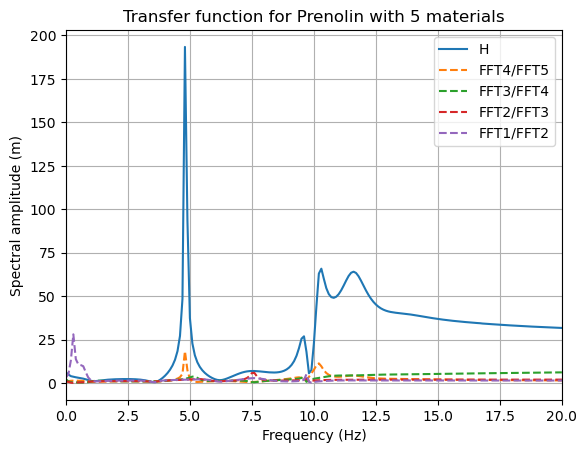

In [22]:
plt.plot(freq, FFT1/FFT5,label="H")
plt.plot(freq, FFT4/FFT5,ls='--', label="FFT4/FFT5")
plt.plot(freq, FFT3/FFT4,ls='--', label="FFT3/FFT4")
plt.plot(freq, FFT2/FFT3,ls='--', label="FFT2/FFT3")
plt.plot(freq, FFT1/FFT2,ls='--', label="FFT1/FFT2")
#plt.xscale('lin')
#plt.yscale('lin')
plt.title("Transfer function for Prenolin with 5 materials")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Spectral amplitude (m)")
plt.xlim([0,20])
plt.legend()
plt.grid(True)